In [1]:
import sys
# sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching")
# sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching\demo-code\2d")
import torch
torch.set_default_device("cuda")
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import h5py
from collections import defaultdict
import numpy as np
from rich import print
import math
from tqdm.auto import tqdm

from models import HCDFlowResMLP, HCDFlow
from metrics import sa,l1, l2, pcc
from utils import plot_intensity, create_fragment_mask_from_peptide, create_batch_fragment_mask_from_peptide

In [28]:
file_path = r"E:\Dai hoc\2526I\dacn\flow-matching\data\holdout_hcd.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:", list(f.keys()))

    seqs = f["sequence_integer"][:]
    charges_oh = f["precursor_charge_onehot"][:]
    intensities_raw = f["intensities_raw"][:]

Keys:
[
    'collision_energy',
    'collision_energy_aligned',
    'collision_energy_aligned_normed',
    'intensities_raw',
    'masses_pred',
    'masses_raw',
    'method',
    'precursor_charge_onehot',
    'rawfile',
    'reverse',
    'scan_number',
    'score',
    'sequence_integer'
]

In [114]:
print(sum(intensities[0] != -1))

44

In [3]:
print(sum(create_fragment_mask_from_peptide(seqs[0], np.argmax(charges_oh[0]) + 1)))

44.0

In [4]:
create_fragment_mask_from_peptide(seqs[0], np.argmax(charges_oh[0]) + 1)

array([1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [17]:
batch_seqs = torch.from_numpy(seqs[8:16]).to(device="cuda")

lengths = (batch_seqs != 0).sum(dim=1)

In [14]:
lengths

tensor([12,  7,  7,  7, 20, 20, 20, 20])

In [15]:
frag_range = torch.arange(1, 30).unsqueeze(0).repeat(8, 1)

In [18]:
valid_mask = frag_range < lengths.unsqueeze(1)

In [29]:
intensities = torch.tensor(intensities_raw[8:16])

In [27]:
idx_base_b = frag_range - 1
idx_b = torch.stack([
            0 * 29 + idx_base_b,
            1 * 29 + idx_base_b,
            2 * 29 + idx_base_b
        ], dim=2).clamp(min=0)
y_pos = lengths.unsqueeze(1) - frag_range
idx_base_y = y_pos - 1

idx_y = torch.stack([
    87 + 0 * 29 + idx_base_y,
    87 + 1 * 29 + idx_base_y,
    87 + 2 * 29 + idx_base_y
], dim=2).clamp(min=0)

In [33]:
idx_b

tensor([[[ 0, 29, 58],
         [ 1, 30, 59],
         [ 2, 31, 60],
         [ 3, 32, 61],
         [ 4, 33, 62],
         [ 5, 34, 63],
         [ 6, 35, 64],
         [ 7, 36, 65],
         [ 8, 37, 66],
         [ 9, 38, 67],
         [10, 39, 68],
         [11, 40, 69],
         [12, 41, 70],
         [13, 42, 71],
         [14, 43, 72],
         [15, 44, 73],
         [16, 45, 74],
         [17, 46, 75],
         [18, 47, 76],
         [19, 48, 77],
         [20, 49, 78],
         [21, 50, 79],
         [22, 51, 80],
         [23, 52, 81],
         [24, 53, 82],
         [25, 54, 83],
         [26, 55, 84],
         [27, 56, 85],
         [28, 57, 86]],

        [[ 0, 29, 58],
         [ 1, 30, 59],
         [ 2, 31, 60],
         [ 3, 32, 61],
         [ 4, 33, 62],
         [ 5, 34, 63],
         [ 6, 35, 64],
         [ 7, 36, 65],
         [ 8, 37, 66],
         [ 9, 38, 67],
         [10, 39, 68],
         [11, 40, 69],
         [12, 41, 70],
         [13, 42, 71],
         

In [43]:
intensities[0][2]

tensor(-1., device='cuda:0', dtype=torch.float64)

In [52]:
intensities_raw[10000]

array([ 0.41201185,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.25094858,  0.        ,  0.        ,  0.82510157,
        0.        ,  0.        ,  0.26722703,  0.02390725,  0.        ,
        0.22593378,  0.        ,  0.        ,  0.06114441,  0.        ,
        0.        ,  0.20022135,  0.01762638,  0.        ,  0.34997671,
        0.0292566 ,  0.        ,  0.15811204,  0.02724477,  0.        ,
        0.40306999,  0.14980633,  0.        ,  0.08040485,  0.        ,
        0.        ,  0.24455423,  0.04262477,  0.        ,  0.        ,
        0.        ,  0.        ,  0.30204006,  0.04325395,  0.        ,
        0.00972321,  0.        ,  0.        ,  0.40621113,  1.        ,
        0.        ,  0.01096815,  0.        ,  0.        ,  0.01912912,
        0.62965844,  0.00685903,  0.        ,  0.09713758,  0.        ,
        0.        ,  0.36546922,  0.        ,  0.        ,  0.01527654,
        0.        , -1.        , -1.        , -1.        , -1.  

In [45]:
seqs[0], charges_oh[0]

(array([20, 18, 18, 18, 20,  5, 15,  4,  8,  3, 17,  9,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 array([0, 1, 0, 0, 0, 0]))

In [ ]:
idx_y

tensor([[[ 97, 126, 155],
         [ 96, 125, 154],
         [ 95, 124, 153],
         [ 94, 123, 152],
         [ 93, 122, 151],
         [ 92, 121, 150],
         [ 91, 120, 149],
         [ 90, 119, 148],
         [ 89, 118, 147],
         [ 88, 117, 146],
         [ 87, 116, 145],
         [ 86, 115, 144],
         [ 85, 114, 143],
         [ 84, 113, 142],
         [ 83, 112, 141],
         [ 82, 111, 140],
         [ 81, 110, 139],
         [ 80, 109, 138],
         [ 79, 108, 137],
         [ 78, 107, 136],
         [ 77, 106, 135],
         [ 76, 105, 134],
         [ 75, 104, 133],
         [ 74, 103, 132],
         [ 73, 102, 131],
         [ 72, 101, 130],
         [ 71, 100, 129],
         [ 70,  99, 128],
         [ 69,  98, 127]],

        [[ 92, 121, 150],
         [ 91, 120, 149],
         [ 90, 119, 148],
         [ 89, 118, 147],
         [ 88, 117, 146],
         [ 87, 116, 145],
         [ 86, 115, 144],
         [ 85, 114, 143],
         [ 84, 113, 142],
         [

In [61]:
seqs[1234]

array([15, 13,  4, 18,  3, 13, 10, 13,  5, 13,  6, 13,  5, 13,  1,  6, 13,
       10,  1, 18,  1,  6,  6, 13, 15,  0,  0,  0,  0,  0])

In [65]:
charges_oh[9]

array([0, 1, 0, 0, 0, 0])

In [62]:
intensities_raw[9]

array([ 0.1052859 ,  0.        , -1.        ,  0.        ,  0.        ,
       -1.        ,  0.        ,  0.        , -1.        ,  0.34984777,
        0.        , -1.        ,  0.19542457,  0.        , -1.        ,
        0.08102787,  0.        , -1.        ,  0.4253483 ,  0.        ,
       -1.        ,  0.        ,  0.        , -1.        ,  0.76606152,
        0.75351677, -1.        ,  0.        ,  0.        , -1.        ,
        0.14261709,  1.        , -1.        ,  0.        ,  0.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.  

In [ ]:
intensities_raw[1231][87:90]s

array([ 0.00506221,  0.00609472, -1.        ])

In [53]:
expanded = intensities.unsqueeze(1).expand(-1, 29, -1)

b_vals = torch.gather(expanded, 2, idx_b)
y_vals = torch.gather(expanded, 2, idx_y)
y_vals

tensor([[[-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000],
         [-1

In [ ]:
alter_inten = intensities[0].copy()
alter_inten[alter_inten > -1] = 1
alter_inten[alter_inten == -1] = 0
alter_inten

array([1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [3]:
pairs = [ (tuple(seqs[i]), tuple(charges_oh[i])) for i in range(len(seqs)) ]

pair_indices = defaultdict(list)

for idx, pair in enumerate(pairs):
    pair_indices[pair].append(idx)

print(f"Distinct pep: {len(pair_indices.keys())}")

Distinct pep: 63491

In [4]:
filtered_indices = []
max_len_pair = None
for pair, indices in pair_indices.items():
    if len(indices) > 10:
        filtered_indices.append(pair)

    if len(indices) > len(pair_indices.get(max_len_pair, [])):
        max_len_pair = pair

# filtered_indices = np.array(filtered_indices)

print("num pep that have more than 10 sample", len(filtered_indices))
print(f"pair that have most indices: {len(pair_indices.get(max_len_pair))}")

num pep that have more than 10 sample 37278

pair that have most indices: 54

In [5]:
pair_indices.get(max_len_pair)


[8469,
 8470,
 8471,
 8472,
 8473,
 8474,
 8475,
 8476,
 8477,
 8478,
 8479,
 8480,
 8481,
 8482,
 8483,
 8484,
 8485,
 8486,
 8487,
 8488,
 8489,
 8490,
 8491,
 8492,
 8493,
 8494,
 8495,
 8496,
 8497,
 8498,
 8499,
 8500,
 8501,
 8502,
 8503,
 8504,
 8505,
 8506,
 8507,
 8508,
 8509,
 8510,
 8511,
 8512,
 8513,
 8514,
 8515,
 8516,
 8517,
 8518,
 8519,
 8520,
 8521,
 8522]

In [6]:
charges = np.argmax(charges_oh, axis=1) + 1

In [7]:
chosen_indices =[8469,
 8470,
 8471, 0]

In [32]:
batch_np_mask = create_batch_fragment_mask_from_peptide(seqs[chosen_indices], charges[chosen_indices], reshape=False)

In [9]:
token_inten = torch.tensor(intensities[8481].copy().reshape(29, 6))
token_inten2 = torch.tensor(intensities[8469].copy().reshape(29,6))

In [123]:
token_inten[token_inten != -1] = 1
token_inten[token_inten == -1] = 0
token_inten2[token_inten2 != -1] = 1
token_inten2[token_inten2 == -1] = 0

In [124]:
token_inten

tensor([[1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]], device='cuda:

In [215]:
import torch.nn.functional as F
def masked_mse_loss(pred, target, mask, eps=1e-8):
    valid_index = mask == 1

    valid_pred = pred[valid_index]
    valid_target = target[valid_index]

    if valid_pred.numel() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    loss = F.mse_loss(valid_pred, valid_target)
    return loss


In [29]:
batch_intensities = torch.tensor(intensities[chosen_indices].copy())

In [30]:
batch_intensities2 = torch.tensor(intensities[[1,2,3,4]].copy())

In [10]:
def pcc(intensity_1, intensity_2, mask=None):
    eps = 1e-8
    # Xác định các chiều cần tính toán (bỏ qua chiều 0 là Batch)
    # Nếu (B, D) -> dims = (1,)
    # Nếu (B, L, D) -> dims = (1, 2)
    dims = tuple(range(1, intensity_1.dim()))

    x, y = intensity_1, intensity_2

    if mask is not None:
        x = x * mask
        y = y * mask
        n = mask.sum(dim=dims, keepdim=True) + eps
        x_mean = x.sum(dim=dims, keepdim=True) / n
        y_mean = y.sum(dim=dims, keepdim=True) / n
        x_centered = (x - x_mean) * mask
        y_centered = (y - y_mean) * mask
    else:
        x_mean = x.mean(dim=dims, keepdim=True)
        y_mean = y.mean(dim=dims, keepdim=True)
        x_centered = x - x_mean
        y_centered = y - y_mean

    numerator = (x_centered * y_centered).sum(dim=dims)
    denominator = torch.sqrt(
        (x_centered**2).sum(dim=dims) * (y_centered**2).sum(dim=dims)
    ) + eps

    pcc_values = numerator / denominator # Shape: (B,)
    return pcc_values.mean().item(), pcc_values.min().item()
def sa(intensity_1, intensity_2, mask=None):
    eps = 1e-8
    dims = tuple(range(1, intensity_1.dim()))

    if mask is not None:
        intensity_1 = intensity_1 * mask
        intensity_2 = intensity_2 * mask

    # Dot product tổng hợp trên tất cả các chiều của mẫu
    dot_product = (intensity_1 * intensity_2).sum(dim=dims)

    # Norm tổng hợp
    norm_1 = torch.sqrt((intensity_1**2).sum(dim=dims))
    norm_2 = torch.sqrt((intensity_2**2).sum(dim=dims))

    sa_values = dot_product / (norm_1 * norm_2 + eps) # Shape: (B,)

    return sa_values.mean().item(), sa_values.min().item()

In [33]:
batch_mask = torch.tensor(batch_np_mask, dtype=torch.bool)

In [36]:
sa(batch_intensities, batch_intensities, mask=batch_mask)

(0.9999999946780349, 0.9999999929987865)

In [ ]:
# (0.999999993525603, 0.9999999914879426)
# (0.9999999996924452, 0.9999999996593184)
const_noise = torch.randn_like(batch_intensities)

In [212]:
noise = const_noise.clone().detach().requires_grad_(True)

In [213]:
print(noise.grad)

None

In [216]:
loss = masked_mse_loss(noise, batch_intensities, batch_mask)
loss.backward()

In [218]:
noise.grad

tensor([[[ 0.0055, -0.0143,  0.0000,  0.0165,  0.0258,  0.0000],
         [ 0.0120,  0.0152,  0.0000, -0.0329, -0.0088,  0.0000],
         [-0.0149,  0.0130,  0.0000,  0.0292, -0.0085,  0.0000],
         [ 0.0016,  0.0094,  0.0000,  0.0375, -0.0305,  0.0000],
         [-0.0248, -0.0147,  0.0000,  0.0053, -0.0243,  0.0000],
         [-0.0220, -0.0228,  0.0000, -0.0205, -0.0320,  0.0000],
         [-0.0130, -0.0342,  0.0000, -0.0025,  0.0068,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.000

In [157]:
batch_mask.shape

torch.Size([4, 29, 6])

In [163]:
batch_mask.unique()

tensor([False,  True], device='cuda:0')

In [160]:
(batch_intensities * batch_mask)

tensor([[[1.2405e-02, 0.0000e+00, -0.0000e+00, 0.0000e+00, 0.0000e+00,
          -0.0000e+00],
         [8.3300e-02, 0.0000e+00, -0.0000e+00, 3.0341e-01, 0.0000e+00,
          -0.0000e+00],
         [9.0819e-02, 0.0000e+00, -0.0000e+00, 1.9926e-01, 0.0000e+00,
          -0.0000e+00],
         [4.8939e-02, 9.5559e-04, -0.0000e+00, 2.1863e-03, 0.0000e+00,
          -0.0000e+00],
         [8.0447e-01, 1.0000e+00, -0.0000e+00, 1.2255e-03, 0.0000e+00,
          -0.0000e+00],
         [1.6776e-01, 4.3758e-01, -0.0000e+00, 2.7773e-03, 0.0000e+00,
          -0.0000e+00],
         [2.0843e-03, 2.5614e-03, -0.0000e+00, 4.4982e-04, 0.0000e+00,
          -0.0000e+00],
         [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
          -0.0000e+00],
         [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
          -0.0000e+00],
         [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
          -0.0000e+00],
         [-0.0000e+00, -0.0000e+00, -0

In [154]:
batch_intensities[batch_mask == 1].shape

torch.Size([128])

In [ ]:
np.argmax(charges_oh[0], axis=0) + 1

np.int64(2)

In [ ]:
alter_intensity = intensities[8481].copy()
# alter_intensity[alter_intensity == -1] = 0.5

In [162]:
x = torch.tensor([[1.],[2.],[3.]], requires_grad=True)
mask = torch.tensor([1,0,1])

y = x[mask==1]
loss = (y**2).mean()
loss.backward()

print(x.grad)

tensor([[1.],
        [0.],
        [3.]], device='cuda:0')

In [ ]:
np.count_nonzero(mask)

np.int64(102)

In [ ]:
mask = create_fragment_mask_from_peptide(seqs[8481], np.argmax(charges_oh[8481]) + 1)

In [ ]:
alter_intensity[alter_intensity != -1] = 1

In [ ]:
alter_intensity[alter_intensity == -1] = 0

In [ ]:
alter_intensity - mask

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [ ]:
np.argmax(intensities[8481]) + 1

np.int64(25)

In [ ]:
mask

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [ ]:
seqs[8481]

array([ 4, 10, 20, 13, 18,  4,  5, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [ ]:
charges_oh[8481]

array([0, 1, 0, 0, 0, 0])

In [6]:
sa(torch.tensor(intensities[8481]).unsqueeze(0), torch.tensor(intensities[8469]).unsqueeze(0), torch.tensor(mask).unsqueeze(0))

NameError: name 'mask' is not defined

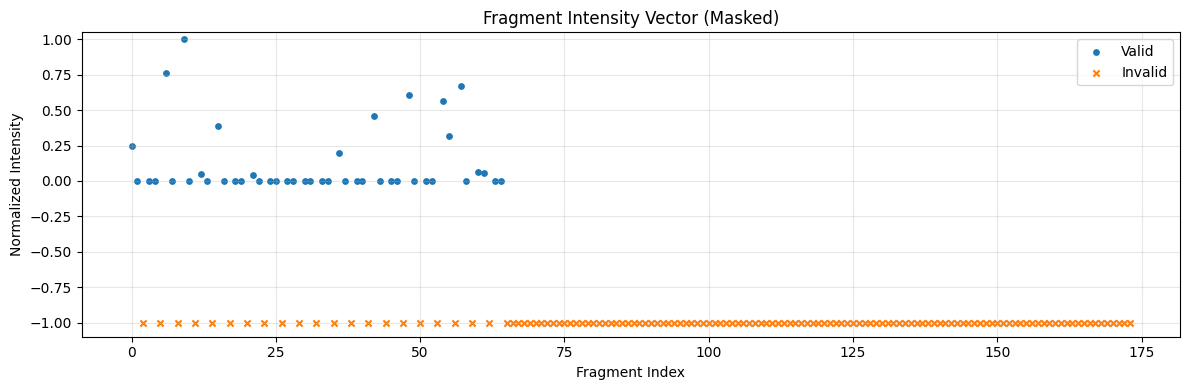

In [ ]:
plot_intensity(intensities[0], seqs[0], np.argmax(charges_oh[0], axis=0) + 1, allow_invalid=True)

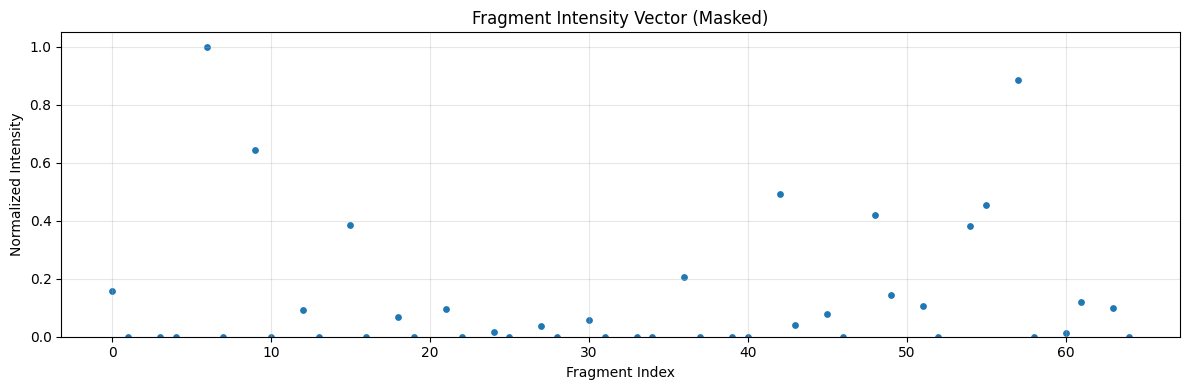

In [ ]:
plot_intensity(intensities[2], seqs[0], np.argmax(charges_oh[0]) + 1, allow_invalid=True)

In [ ]:
model_path = r"E:\Dai hoc\2526I\dacn\flow-matching\run_real_data\checkpoints\tfmemb_adalm8_512_8e.pth"
model = HCDFlowResMLP(noise_dim=174, pep_dim=256, time_dim=128, charge_dim=9, num_blocks=8, min_charge=1, max_charge=6)
model.load_state_dict(torch.load(model_path))
model.eval()

HCDFlowResMLP(
  (cond_embedding): TfmEmbedding(
    (pep_embedding): Embedding(22, 256, padding_idx=0)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (charge_embedding): ChargeEmbedding(
      (emb): Embedding(6, 8)
      (ln): LayerNorm((9,), eps=1e-05, elementwise_affine=True)
    )
  )
  (mlp): 

In [ ]:
np.argmax(charges_oh[0])

np.int64(1)

In [ ]:
sample_seq = torch.tensor(list(seqs[0]), dtype=torch.long).unsqueeze(0)
sample_charge = torch.tensor(np.argmax(charges_oh[0]), dtype=torch.long).unsqueeze(0).unsqueeze(0)

In [ ]:
noise = torch.randn_like(torch.tensor(intensities[0], dtype=torch.float32)).unsqueeze(0)

In [ ]:
plot_intensity(noise[0].cpu().numpy(), seqs[0], np.argmax(charges_oh[0]) + 1, allow_invalid=True)

NameError: name 'noise' is not defined

In [ ]:
generated = model.sample(noise, sample_seq, sample_charge)

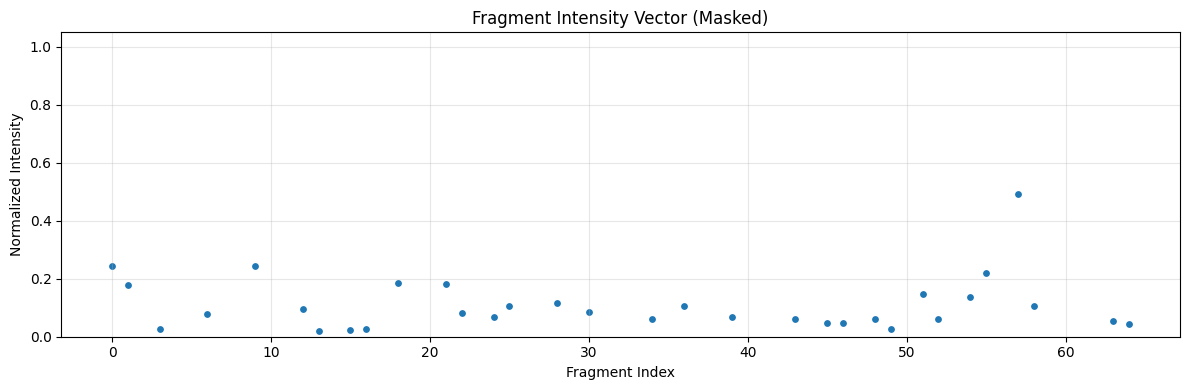

In [ ]:
plot_intensity(generated[0], seqs[0], np.argmax(charges_oh[0]) + , allow_invalid=False)

In [ ]:
pcc(generated, torch.tensor(intensities[0]).unsqueeze(0))

(0.22110285910080743, 0.22110285910080743)

In [ ]:
from models.transformer import DiffusionFlow
from torchsummary import summary
from torchinfo import summary as info
import torch

In [ ]:
flow = DiffusionFlow(6, 256, num_layers=2, num_pep_layers=4)
flow.train()

DiffusionFlow(
  (pep_embedding): PepEmbedding(
    (pep_embedding): Embedding(22, 256, padding_idx=0)
    (tfm): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (noise_projection): NoiseProjection(
    (projection): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): GELU(approximate='n

In [ ]:
info(
    flow,
    input_data=(
        torch.randn(2, 29, 6),          # noise
        torch.randint(0, 22, (2, 30)).long(),  # pep
        torch.randint(1, 5, (2,1)).long(),      # charge
        torch.rand(2 ,1)                   # time
    )
)

Layer (type:depth-idx)                             Output Shape              Param #
DiffusionFlow                                      [2, 29, 6]                --
├─NoiseProjection: 1-1                             [2, 29, 256]              --
│    └─Sequential: 2-1                             [2, 29, 256]              --
│    │    └─Linear: 3-1                            [2, 29, 64]               448
│    │    └─GELU: 3-2                              [2, 29, 64]               --
│    │    └─Linear: 3-3                            [2, 29, 256]              16,640
│    │    └─LayerNorm: 3-4                         [2, 29, 256]              512
├─PepEmbedding: 1-2                                [2, 30, 256]              --
│    └─Embedding: 2-2                              [2, 30, 256]              5,632
│    └─TransformerEncoder: 2-3                     [2, 30, 256]              --
│    │    └─ModuleList: 3-5                        --                        2,108,416
├─ChargeEmbedding: 

In [ ]:
B = 4          # batch size
L = 12         # peptide length

noise = torch.randn(B, 29, 6)

pep_seq = torch.randint(
    low=0,
    high=20,
    size=(B, L)
).long()

charge = torch.randint(
    low=1,
    high=4,
    size=(B,)
).long().unsqueeze(1)

# ===== run sampling =====
with torch.no_grad():

    out = flow.sample(
        noise=noise,
        pep_seq=pep_seq,
        charge=charge,
        step=10
    )

print("Input noise shape :", noise.shape)
print("Output shape      :", out.shape)

Input noise shape : torch.Size([4, 29, 6])
Output shape      : torch.Size([4, 29, 6])


In [ ]:
pccc

In [ ]:
print(sum(p.numel() for p in flow.parameters() if p.requires_grad))


3488682


In [ ]:
print(flow.peptide_embedding.pep_embedding.num_embeddings)

22
